# Taller 4: Optimización de despliegue PON

Integrantes:
* Camila Herrera
* Gustavo Venegas
* Javier Cáceres

## Secciones del Jupyter

1. Preparar herramientas (instalaciones e imports + Numba).
2. Seleccionar áreas de estudio (Urbana, Semi-Urbana, Rural).
3. Extraer topología de OpenStreetMap (OSMnx) para cada área.
4. Generar usuarios y calcular posiciones de splitters basado en clustering.
5. Calcular rutas con distancia Manhattan desde splitters a usuarios.
6. Calcular Power Budget para validación de transmisión.
7. **Bucle iterativo**: Formular y resolver ILP con restricciones de Power Budget.
8. Si hay usuarios sin cobertura, reposicionar splitters y volver a paso 7.
9. Validar presupuesto óptico y latencia del diseño final.
10. Visualización del resultado (mapas estático e interactivo).

## 1. Preparación: instalación e imports

Se preparan las herramientas y librerías necesarias, definiendo parámetros globales del modelo:

**Parámetros económicos:**
- Costo de fibra por metro y costo de splitters

**Parámetros del Power Budget (GPON):**
- **Potencia transmitida (OLT)**: Típicamente +2 a +7 dBm (clase B+)
- **Sensibilidad del receptor (ONU)**: -28 dBm (clase B+)
- **Margen de sistema**: 3 dB (reserva para degradación y mantenimiento)
- **Atenuación de fibra**: 0.35 dB/km
- **Pérdidas por conectores y empalmes**
- **Pérdida por splitter**: según ratio (tabla ITU-T)

El **Power Budget** máximo disponible determina el alcance y topología factible.

In [16]:
# Imports necesarios
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp
from shapely.geometry import Point, Polygon
import heapq
from sklearn.cluster import KMeans, DBSCAN
import numba
from numba import jit, prange
import warnings
warnings.filterwarnings('ignore')

# Parámetros del modelo económico
COST_FIBER_PER_M = 1.0    # Costo unitario por metro de fibra
COST_SPLITTER = 200.0      # Costo de instalación de splitter
SPLIT_RATIO = 32           # Capacidad máxima: usuarios por splitter (1:32)

# Parámetros del Power Budget (GPON clase B+)
TX_POWER_DBM = 5.0         # Potencia transmitida por OLT (dBm)
RX_SENSITIVITY_DBM = -28.0 # Sensibilidad del receptor ONU (dBm)
SYSTEM_MARGIN_DB = 3.0     # Margen de sistema para degradación
POWER_BUDGET_DB = TX_POWER_DBM - RX_SENSITIVITY_DBM - SYSTEM_MARGIN_DB  # 30 dB disponible

# Parámetros físicos de atenuación
FIBER_ATTEN_DB_PER_KM = 0.35
CONNECTOR_LOSS_DB = 0.5
SPLICE_LOSS_DB_PER_KM = 0.1
SPLITTER_LOSS_TABLE = {2:3.5, 4:7.0, 8:10.5, 16:13.5, 32:17.5}  # Valores ITU-T

# Alcance máximo derivado del Power Budget
RMAX = 20000.0  # metros (conservador, se validará con Power Budget)

# Parámetros de iteración
MAX_ITERATIONS = 5  # Máximo de iteraciones para reubicación de splitters
MIN_COVERAGE = 0.95  # Cobertura mínima requerida (95% de usuarios)

print('osmnx', ox.__version__)
print('networkx', nx.__version__)
print('numba', numba.__version__)
print(f'Power Budget disponible: {POWER_BUDGET_DB:.1f} dB')

osmnx 2.0.6
networkx 3.5
numba 0.62.1
Power Budget disponible: 30.0 dB


## 2. Definición de áreas de estudio

En lugar de utilizar toda la ciudad de Valparaíso, se definen **tres áreas específicas** que representan diferentes escenarios de despliegue:

1. **Área Urbana**: Zona densa del centro de Valparaíso (alta densidad de usuarios)
2. **Área Semi-Urbana**: Zona residencial periférica (densidad media)
3. **Área Rural**: Zona con menor densidad poblacional

Cada área se define mediante un polígono específico o un punto central con radio. Esto permite analizar diferentes estrategias de despliegue según la densidad de usuarios y características del terreno.

In [17]:
# Definición de áreas de estudio
# Seleccionar UNA de las siguientes áreas para el análisis

AREA_TYPE = 'urbana'  # Opciones: 'urbana', 'semi_urbana', 'rural'

areas = {
    'urbana': {
        'point': (-33.0472, -71.6127),  # Centro de Valparaíso
        'radius': 500,  # metros
        'num_users': 100,
        'description': 'Zona urbana densa - Centro Valparaíso'
    },
    'semi_urbana': {
        'point': (-33.0350, -71.5950),  # Zona residencial Viña del Mar
        'radius': 800,  # metros
        'num_users': 60,
        'description': 'Zona semi-urbana - Residencial'
    },
    'rural': {
        'point': (-33.0100, -71.5500),  # Zona más alejada
        'radius': 1200,  # metros
        'num_users': 30,
        'description': 'Zona rural - Baja densidad'
    }
}

area_config = areas[AREA_TYPE]
print(f"Área seleccionada: {AREA_TYPE.upper()}")
print(f"Descripción: {area_config['description']}")
print(f"Radio: {area_config['radius']} m")
print(f"Usuarios esperados: {area_config['num_users']}")

# Descargar grafo vial del área específica
G = ox.graph_from_point(
    area_config['point'], 
    dist=area_config['radius'], 
    network_type='drive'
)
G = ox.project_graph(G)

# Extraer nodos y aristas como GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
assert set(nodes_gdf.index) == set(G.nodes), "Los índices de nodes_gdf no coinciden con G.nodes"

print(f'\nNodos totales en el área: {len(nodes_gdf)}')
print(f'Aristas totales: {len(edges_gdf)}')

Área seleccionada: URBANA
Descripción: Zona urbana densa - Centro Valparaíso
Radio: 500 m
Usuarios esperados: 100

Nodos totales en el área: 135
Aristas totales: 290

Nodos totales en el área: 135
Aristas totales: 290


## 2.5. Visualización del área seleccionada

Mapa interactivo mostrando el área de estudio extraída de OpenStreetMap.

In [32]:
import folium
from folium import plugins

# Convertir nodos a WGS84 para visualización en folium
nodes_wgs84_preview = nodes_gdf.to_crs(epsg=4326)

# Calcular centro del área
center_lat = nodes_wgs84_preview.geometry.y.mean()
center_lon = nodes_wgs84_preview.geometry.x.mean()

# Crear mapa base
map_area = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=15, 
    tiles='OpenStreetMap'
)

# Agregar red vial como líneas grises
for idx, edge in edges_gdf.iterrows():
    if hasattr(edge.geometry, 'coords'):
        coords = list(edge.geometry.coords)
        # Convertir a lat/lon
        coords_wgs84 = []
        for coord in coords:
            point = gpd.GeoSeries([Point(coord)], crs=nodes_gdf.crs).to_crs(epsg=4326)
            coords_wgs84.append([point.iloc[0].y, point.iloc[0].x])
        
        folium.PolyLine(
            coords_wgs84,
            color='gray',
            weight=1,
            opacity=0.4
        ).add_to(map_area)

# Marcar el centro del área con un círculo
folium.Circle(
    location=[center_lat, center_lon],
    radius=area_config['radius'],
    color='blue',
    fill=True,
    fillColor='blue',
    fillOpacity=0.1,
    popup=folium.Popup(
        f"<b>Área: {AREA_TYPE.upper()}</b><br>"
        f"Radio: {area_config['radius']} m<br>"
        f"Usuarios esperados: {area_config['num_users']}<br>"
        f"Nodos: {len(nodes_gdf)}<br>"
        f"Descripción: {area_config['description']}",
        max_width=300
    ),
    tooltip=f"Área {AREA_TYPE} - Radio: {area_config['radius']}m"
).add_to(map_area)

# Marcar centro exacto
folium.Marker(
    location=[area_config['point'][0], area_config['point'][1]],
    popup=f"<b>Centro del área {AREA_TYPE}</b>",
    tooltip="Punto central",
    icon=folium.Icon(color='blue', icon='circle', prefix='fa')
).add_to(map_area)

# Agregar control de pantalla completa
plugins.Fullscreen().add_to(map_area)

# Leyenda
legend_html = f'''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 220px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:12px; padding: 10px">
<p><b>Área de Estudio: {AREA_TYPE.upper()}</b></p>
<p><span style="color:gray">━</span> Red vial</p>
<p><span style="color:blue">○</span> Área de cobertura ({area_config['radius']}m)</p>
<p><b>Nodos:</b> {len(nodes_gdf)}</p>
<p><b>Aristas:</b> {len(edges_gdf)}</p>
<p><b>Usuarios esperados:</b> {area_config['num_users']}</p>
</div>
'''
map_area.get_root().html.add_child(folium.Element(legend_html))

# Mostrar mapa
print(f"\nMapa del área '{AREA_TYPE}' generado:")
print(f"  Centro: {area_config['point']}")
print(f"  Radio: {area_config['radius']} metros")
print(f"  Descripción: {area_config['description']}")
print(f"  Red vial: {len(nodes_gdf)} nodos, {len(edges_gdf)} aristas")

map_area


Mapa del área 'urbana' generado:
  Centro: (-33.0472, -71.6127)
  Radio: 500 metros
  Descripción: Zona urbana densa - Centro Valparaíso
  Red vial: 135 nodos, 290 aristas


## 3. Generación de usuarios

Se generan usuarios sintéticos dentro del área seleccionada. Los usuarios se distribuyen:
- En **áreas urbanas**: más concentrados cerca de intersecciones
- En **áreas semi-urbanas**: distribución intermedia
- En **áreas rurales**: más dispersos

In [19]:
# Generar usuarios sintéticos según el área
num_users = area_config['num_users']

# Muestreo de nodos para representar ubicaciones de usuarios
available_nodes = list(nodes_gdf.index)
if len(available_nodes) < num_users:
    print(f"Advertencia: Solo hay {len(available_nodes)} nodos disponibles, ajustando cantidad de usuarios")
    num_users = len(available_nodes)

user_node_ids = np.random.choice(available_nodes, size=num_users, replace=False)

users_gdf = nodes_gdf.loc[user_node_ids, ['x', 'y']].copy()
users_gdf['geometry'] = users_gdf.apply(lambda r: Point(r.x, r.y), axis=1)
users_gdf = gpd.GeoDataFrame(users_gdf, geometry='geometry', crs=nodes_gdf.crs)
users_gdf['node_id'] = users_gdf.index
users_gdf['user_id'] = range(len(users_gdf))

print(f'Usuarios generados: {len(users_gdf)}')

Usuarios generados: 100


## 4. Posicionamiento de splitters basado en clustering

**Nuevo enfoque**: En lugar de seleccionar splitters únicamente por intersecciones con alta conectividad, se utiliza **clustering de usuarios** para:

1. Agrupar usuarios en clusters según su proximidad espacial
2. Calcular centroides de cada cluster
3. Ubicar splitters en el nodo de calle más cercano a cada centroide

Este método garantiza que:
- Los splitters estén cerca de grupos de usuarios
- Se respete la infraestructura vial existente
- La cantidad de splitters se adapte automáticamente al número de usuarios

In [20]:
def position_splitters_by_clustering(users_gdf, nodes_gdf, G, n_splitters=None):
    """
    Posiciona splitters usando clustering de usuarios.
    
    Args:
        users_gdf: GeoDataFrame con ubicaciones de usuarios
        nodes_gdf: GeoDataFrame con nodos de la red vial
        G: Grafo de la red vial
        n_splitters: Número de splitters (si None, se calcula automáticamente)
    
    Returns:
        candidate_nodes: GeoDataFrame con posiciones de splitters
    """
    # Calcular número óptimo de splitters si no se especifica
    if n_splitters is None:
        n_splitters = max(1, int(np.ceil(len(users_gdf) / SPLIT_RATIO)))
    
    print(f"Calculando {n_splitters} posiciones de splitters para {len(users_gdf)} usuarios...")
    
    # Extraer coordenadas de usuarios
    user_coords = np.column_stack([users_gdf.geometry.x, users_gdf.geometry.y])
    
    # Aplicar K-Means clustering
    kmeans = KMeans(n_clusters=n_splitters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(user_coords)
    centroids = kmeans.cluster_centers_
    
    users_gdf['cluster'] = clusters
    
    # Para cada centroide, encontrar el nodo de calle más cercano
    splitter_nodes = []
    for i, centroid in enumerate(centroids):
        # Calcular distancias euclidianas a todos los nodos
        distances = np.sqrt(
            (nodes_gdf.geometry.x - centroid[0])**2 + 
            (nodes_gdf.geometry.y - centroid[1])**2
        )
        
        # Seleccionar nodo más cercano
        nearest_node = distances.idxmin()
        splitter_nodes.append(nearest_node)
        
        users_in_cluster = (clusters == i).sum()
        print(f"  Cluster {i}: {users_in_cluster} usuarios → Splitter en nodo {nearest_node}")
    
    # Crear GeoDataFrame de splitters
    candidate_nodes = nodes_gdf.loc[splitter_nodes].copy()
    candidate_nodes['splitter_id'] = range(len(candidate_nodes))
    candidate_nodes['node_id'] = candidate_nodes.index
    
    return candidate_nodes, users_gdf

# Ejecutar posicionamiento de splitters
candidate_nodes, users_gdf = position_splitters_by_clustering(users_gdf, nodes_gdf, G)

print(f'\nSplitters candidatos generados: {len(candidate_nodes)}')
print(f'Ratio promedio: {len(users_gdf)/len(candidate_nodes):.1f} usuarios/splitter')

Calculando 4 posiciones de splitters para 100 usuarios...
  Cluster 0: 26 usuarios → Splitter en nodo 262531896
  Cluster 1: 35 usuarios → Splitter en nodo 579628072
  Cluster 2: 20 usuarios → Splitter en nodo 5316795923
  Cluster 3: 19 usuarios → Splitter en nodo 259214295

Splitters candidatos generados: 4
Ratio promedio: 25.0 usuarios/splitter


## 5. Cálculo de rutas con distancia Manhattan (optimizado con Numba)

Con los splitters ya posicionados, se calculan las rutas Manhattan desde cada splitter a cada usuario.

Se utiliza **Numba** para acelerar los cálculos de distancia y hacer el proceso eficiente incluso con grandes cantidades de datos.

In [21]:
@jit(nopython=True)
def calculate_euclidean_distance(x1, y1, x2, y2):
    """Calcula distancia euclidiana entre dos puntos (optimizado con Numba)."""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def calculate_manhattan_paths(users_gdf, candidate_nodes, G):
    """
    Calcula rutas Manhattan desde splitters a usuarios.
    
    Returns:
        paths_edges: dict con aristas de cada ruta (u,s) -> [edges]
        path_lengths: dict con longitud de cada ruta (u,s) -> length
    """
    candidate_ids = list(candidate_nodes.index)
    user_ids = list(users_gdf['node_id'])
    
    paths_edges = {}
    path_lengths = {}
    
    print(f"Calculando rutas Manhattan para {len(user_ids)} usuarios y {len(candidate_ids)} splitters...")
    
    total_pairs = len(user_ids) * len(candidate_ids)
    computed = 0
    
    for u in user_ids:
        for s in candidate_ids:
            try:
                # Calcular ruta más corta usando Dijkstra
                path_nodes = nx.shortest_path(G, source=s, target=u, weight='length')
                path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))
                
                # Calcular longitud total
                length = sum(
                    G.get_edge_data(e[0], e[1])[0].get('length', 0)
                    if isinstance(G.get_edge_data(e[0], e[1]), dict)
                    else G.get_edge_data(e[0], e[1]).get('length', 0)
                    for e in path_edges
                )
                
                paths_edges[(u, s)] = path_edges
                path_lengths[(u, s)] = length
                computed += 1
                
            except (nx.NetworkXNoPath, KeyError):
                # No hay ruta disponible
                continue
    
    print(f"Rutas calculadas: {computed}/{total_pairs} ({computed/total_pairs*100:.1f}%)")
    return paths_edges, path_lengths

# Calcular todas las rutas
paths_edges, path_lengths = calculate_manhattan_paths(users_gdf, candidate_nodes, G)

if len(path_lengths) == 0:
    raise RuntimeError("No se encontraron rutas válidas. Verificar conectividad del grafo.")

Calculando rutas Manhattan para 100 usuarios y 4 splitters...
Rutas calculadas: 384/400 (96.0%)
Rutas calculadas: 384/400 (96.0%)


## 6. Cálculo del Power Budget (optimizado con Numba)

Se validan las rutas calculadas según el Power Budget disponible. 

**Optimización con Numba**: Las funciones de cálculo de pérdidas están optimizadas con `@jit` para procesar rápidamente grandes volúmenes de datos.

## Fundamentos del Power Budget

El **Power Budget** es fundamental para validar que una ruta puede transmitir señal óptica con calidad suficiente.

### Ecuación del Power Budget:

$$P_{Budget} = P_{TX} - P_{RX_{min}} - Margen_{sistema}$$

### Pérdidas totales del enlace:

$$Pérdida_{total} = \alpha_{fibra} \times L + L_{splitter} + N_{conectores} \times L_{conector} + L_{empalmes}$$

Donde:
- $\alpha_{fibra}$ = 0.35 dB/km (atenuación de fibra)
- $L$ = longitud del enlace (km)
- $L_{splitter}$ = pérdida según ratio (tabla ITU-T)
- $N_{conectores}$ = número de conectores en la ruta
- $L_{empalmes}$ = pérdidas por empalmes (≈0.1 dB/km)

### Restricción crítica:
$$Pérdida_{total} \leq P_{Budget}$$

In [22]:
@jit(nopython=True)
def compute_fiber_loss(path_length_km, fiber_atten_db_per_km):
    """Calcula pérdida por fibra (optimizado con Numba)."""
    return path_length_km * fiber_atten_db_per_km

@jit(nopython=True)
def compute_splice_loss(path_length_km, splice_loss_db_per_km):
    """Calcula pérdida por empalmes (optimizado con Numba)."""
    return path_length_km * splice_loss_db_per_km

def get_splitter_loss(split_ratio):
    """Obtiene pérdida del splitter desde tabla ITU-T."""
    return SPLITTER_LOSS_TABLE.get(split_ratio, 10*np.log10(split_ratio))

def calculate_power_budget(path_length_m, split_ratio, num_connectors=2):
    """
    Calcula el Power Budget requerido para una ruta.
    
    Returns:
        tuple: (total_loss_db, is_feasible, budget_margin_db)
    """
    # Conversión a kilómetros
    path_length_km = path_length_m / 1000.0
    
    # Pérdidas individuales (usar funciones Numba cuando sea posible)
    fiber_loss = compute_fiber_loss(path_length_km, FIBER_ATTEN_DB_PER_KM)
    splitter_loss = get_splitter_loss(split_ratio)
    connector_loss = num_connectors * CONNECTOR_LOSS_DB
    splice_loss = compute_splice_loss(path_length_km, SPLICE_LOSS_DB_PER_KM)
    
    # Pérdida total del enlace
    total_loss = fiber_loss + splitter_loss + connector_loss + splice_loss
    
    # Verificar si cumple con el Power Budget disponible
    is_feasible = total_loss <= POWER_BUDGET_DB
    budget_margin = POWER_BUDGET_DB - total_loss
    
    return total_loss, is_feasible, budget_margin

# Validar rutas según Power Budget
print(f"\nValidando {len(path_lengths)} rutas con Power Budget de {POWER_BUDGET_DB:.1f} dB...")
print("=" * 70)

feasible_pairs = []
infeasible_pairs = []
power_budget_data = {}

for (u, s), length in path_lengths.items():
    loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
    power_budget_data[(u, s)] = {
        'loss': loss,
        'feasible': feasible,
        'margin': margin,
        'length': length
    }
    
    if feasible:
        feasible_pairs.append((u, s))
    else:
        infeasible_pairs.append((u, s))

# Estadísticas
print(f"Pares FACTIBLES (Power Budget):        {len(feasible_pairs)} ({len(feasible_pairs)/len(path_lengths)*100:.1f}%)")
print(f"Pares INFACTIBLES (Power Budget):      {len(infeasible_pairs)} ({len(infeasible_pairs)/len(path_lengths)*100:.1f}%)")

if len(feasible_pairs) > 0:
    feasible_losses = [power_budget_data[pair]['loss'] for pair in feasible_pairs]
    print(f"Pérdida promedio (rutas factibles):    {np.mean(feasible_losses):.2f} dB")
    print(f"Pérdida máxima (rutas factibles):      {np.max(feasible_losses):.2f} dB")
    print(f"Margen mínimo disponible:              {POWER_BUDGET_DB - np.max(feasible_losses):.2f} dB")

print("=" * 70)


Validando 384 rutas con Power Budget de 30.0 dB...
Pares FACTIBLES (Power Budget):        384 (100.0%)
Pares INFACTIBLES (Power Budget):      0 (0.0%)
Pérdida promedio (rutas factibles):    18.80 dB
Pérdida máxima (rutas factibles):      19.18 dB
Margen mínimo disponible:              10.82 dB
Pares FACTIBLES (Power Budget):        384 (100.0%)
Pares INFACTIBLES (Power Budget):      0 (0.0%)
Pérdida promedio (rutas factibles):    18.80 dB
Pérdida máxima (rutas factibles):      19.18 dB
Margen mínimo disponible:              10.82 dB


## 7. Preparación de datos para ILP

Con los splitters posicionados y las rutas validadas por Power Budget, preparamos los datos para el modelo de optimización.

In [23]:
def get_edge_length_safe(G, u, v):
    """Obtiene longitud de arista compatible con MultiDiGraph."""
    ed = G.get_edge_data(u, v)
    if not ed:
        return 0.0
    if isinstance(ed, dict) and all(not isinstance(vv, dict) for vv in ed.values()):
        return float(ed.get('length', 0.0))
    lengths = []
    for key, attr in ed.items():
        if isinstance(attr, dict):
            lengths.append(float(attr.get('length', 0.0)))
    if lengths:
        return min(lengths)
    return 0.0

# Construir conjunto de aristas relevantes (solo de rutas factibles)
relevant_edges = set()
for (u, s) in feasible_pairs:
    edges = paths_edges[(u, s)]
    for e in edges:
        relevant_edges.add(e)

edge_keys = list(relevant_edges)
edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
edge_index_lookup = {edge_keys[i]: i for i in range(len(edge_keys))}

# Crear mapa de longitudes de aristas
edge_length_map = {
    i: get_edge_length_safe(G, edge_index_to_edge[i][0], edge_index_to_edge[i][1])
    for i in edge_index_to_edge.keys()
}

print(f"Aristas relevantes: {len(edge_keys)}")
print(f"Pares factibles para ILP: {len(feasible_pairs)}")

# Obtener IDs finales
candidate_ids = list(candidate_nodes.index)
user_ids = list(users_gdf['node_id'])

Aristas relevantes: 201
Pares factibles para ILP: 384


## 8. Formulación del modelo ILP (simplificado)

**NUEVO ENFOQUE**: El ILP ahora se enfoca **únicamente en la asignación óptima** con las siguientes características:

- **Splitters pre-posicionados**: Ya determinados por clustering (no son variables de decisión)
- **Power Budget pre-validado**: Solo se consideran pares (u,s) que cumplen con el presupuesto óptico
- **Objetivo**: Minimizar costo total de fibra garantizando cobertura completa

### Variables de decisión:
- $x_e$ ∈ {0,1}: instalar fibra en arista $e$
- $z_{u,s}$ ∈ {0,1}: asignar usuario $u$ a splitter $s$

**Nota**: $y_s$ (activación de splitter) se eliminó porque los splitters ya están posicionados.

### Función objetivo:
$$\min \sum_{e} C_{fibra} \cdot L_e \cdot x_e + \sum_{s \in S_{usados}} C_{splitter}$$

### Restricciones:

1. **Asignación única**: $\sum_{s} z_{u,s} = 1 \quad \forall u$

2. **Capacidad de splitter**: $\sum_{u} z_{u,s} \leq R_{split} \quad \forall s$

3. **Conectividad**: $x_e \geq z_{u,s} \quad \forall e \in path(u,s)$

4. **Power Budget** (implícito): Solo pares en `feasible_pairs` están permitidos

In [24]:
def solve_ilp_with_power_budget(feasible_pairs, paths_edges, edge_keys, edge_length_map, 
                                 edge_index_lookup, user_ids, candidate_ids, 
                                 split_ratio=SPLIT_RATIO, time_limit=300):
    """
    Resuelve el ILP con splitters pre-posicionados y Power Budget validado.
    
    Args:
        feasible_pairs: Lista de pares (u,s) que cumplen Power Budget
        paths_edges: Diccionario con aristas de cada ruta
        edge_keys: Lista de aristas relevantes
        edge_length_map: Diccionario con longitud de cada arista
        edge_index_lookup: Mapeo de arista a índice
        user_ids: Lista de IDs de usuarios
        candidate_ids: Lista de IDs de splitters
        split_ratio: Capacidad máxima de splitter
        time_limit: Límite de tiempo en segundos
    
    Returns:
        dict con: status, installed_splitters, installed_edges, assignments, cost
    """
    
    print(f"\n{'='*70}")
    print("FORMULANDO Y RESOLVIENDO ILP")
    print(f"{'='*70}")
    print(f"Usuarios: {len(user_ids)}")
    print(f"Splitters candidatos: {len(candidate_ids)}")
    print(f"Pares factibles (Power Budget): {len(feasible_pairs)}")
    print(f"Aristas relevantes: {len(edge_keys)}")
    
    # Crear problema
    prob = pulp.LpProblem('PON_Optimization_PowerBudget', pulp.LpMinimize)
    
    # Variables de decisión
    xe = pulp.LpVariable.dicts('x_edge', range(len(edge_keys)), cat='Binary')
    zu = pulp.LpVariable.dicts('assign', feasible_pairs, cat='Binary')
    
    # Función objetivo: minimizar costo de fibra + costo de splitters usados
    fiber_cost = pulp.lpSum([COST_FIBER_PER_M * edge_length_map[i] * xe[i] 
                             for i in range(len(edge_keys))])
    
    # Contar splitters únicos usados
    splitters_used = {}
    for s in candidate_ids:
        feasible_u_for_s = [u for (u, ss) in feasible_pairs if ss == s]
        if feasible_u_for_s:
            splitters_used[s] = pulp.lpSum([zu[(u, s)] for u in feasible_u_for_s])
    
    splitter_cost = COST_SPLITTER * len(candidate_ids)  # Simplificación: todos los splitters
    
    prob += fiber_cost + splitter_cost
    
    # Restricción 1: Cada usuario asignado a exactamente un splitter
    for u in user_ids:
        feasible_s_for_u = [s for (uu, s) in feasible_pairs if uu == u]
        if len(feasible_s_for_u) == 0:
            print(f"ADVERTENCIA: Usuario {u} no tiene splitters factibles")
            continue
        prob += pulp.lpSum([zu[(u, s)] for s in feasible_s_for_u]) == 1
    
    # Restricción 2: Capacidad de splitter
    for s in candidate_ids:
        feasible_u_for_s = [u for (u, ss) in feasible_pairs if ss == s]
        if feasible_u_for_s:
            prob += pulp.lpSum([zu[(u, s)] for u in feasible_u_for_s]) <= split_ratio
    
    # Restricción 3: Conectividad (instalar fibra si usuario asignado)
    for (u, s) in feasible_pairs:
        edges = paths_edges[(u, s)]
        for e in edges:
            idx = edge_index_lookup.get(e)
            if idx is None:
                idx = edge_index_lookup.get((e[1], e[0]))
            if idx is not None:
                prob += xe[idx] >= zu[(u, s)]
    
    # Resolver
    print(f"\nResolviendo ILP (límite: {time_limit}s)...")
    solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=time_limit)
    prob.solve(solver)
    
    status = pulp.LpStatus[prob.status]
    print(f'\nEstado de la solución: {status}')
    
    if status != 'Optimal' and status != 'Feasible':
        return {
            'status': status,
            'installed_splitters': [],
            'installed_edges': [],
            'assignments': [],
            'cost': None,
            'uncovered_users': user_ids
        }
    
    # Extraer solución
    installed_edges = [
        edge_index_to_edge[i] for i in range(len(edge_keys)) 
        if pulp.value(xe[i]) and pulp.value(xe[i]) > 0.5
    ]
    
    assignments = [
        (u, s) for (u, s) in feasible_pairs 
        if pulp.value(zu[(u, s)]) and pulp.value(zu[(u, s)]) > 0.5
    ]
    
    # Determinar splitters instalados (los que tienen al menos un usuario)
    installed_splitters = list(set([s for (u, s) in assignments]))
    
    # Calcular costo total
    total_fiber_length = sum([edge_length_map[edge_index_lookup.get(e, edge_index_lookup.get((e[1], e[0])))] 
                              for e in installed_edges])
    total_cost = total_fiber_length * COST_FIBER_PER_M + len(installed_splitters) * COST_SPLITTER
    
    # Usuarios cubiertos vs no cubiertos
    covered_users = set([u for (u, s) in assignments])
    uncovered_users = [u for u in user_ids if u not in covered_users]
    
    print(f'\nSplitters instalados: {len(installed_splitters)}')
    print(f'Aristas de fibra: {len(installed_edges)}')
    print(f'Usuarios asignados: {len(assignments)}/{len(user_ids)}')
    print(f'Usuarios sin cobertura: {len(uncovered_users)}')
    print(f'Costo total: {total_cost:.2f}')
    
    return {
        'status': status,
        'installed_splitters': installed_splitters,
        'installed_edges': installed_edges,
        'assignments': assignments,
        'cost': total_cost,
        'uncovered_users': uncovered_users
    }

# Resolver ILP inicial
solution = solve_ilp_with_power_budget(
    feasible_pairs, paths_edges, edge_keys, edge_length_map,
    edge_index_lookup, user_ids, candidate_ids
)

installed_splitters = solution['installed_splitters']
installed_edges = solution['installed_edges']
assignments = solution['assignments']
uncovered_users = solution['uncovered_users']


FORMULANDO Y RESOLVIENDO ILP
Usuarios: 100
Splitters candidatos: 4
Pares factibles (Power Budget): 384
Aristas relevantes: 201
ADVERTENCIA: Usuario 255386099 no tiene splitters factibles
ADVERTENCIA: Usuario 258021028 no tiene splitters factibles
ADVERTENCIA: Usuario 264676822 no tiene splitters factibles
ADVERTENCIA: Usuario 2791295509 no tiene splitters factibles

Resolviendo ILP (límite: 300s)...

Estado de la solución: Optimal

Splitters instalados: 4
Aristas de fibra: 108
Usuarios asignados: 96/100
Usuarios sin cobertura: 4
Costo total: 8455.52

Estado de la solución: Optimal

Splitters instalados: 4
Aristas de fibra: 108
Usuarios asignados: 96/100
Usuarios sin cobertura: 4
Costo total: 8455.52


## 9. Bucle iterativo: Reposicionamiento de splitters para usuarios sin cobertura

Si hay usuarios sin cobertura después del ILP, se **reposicionan splitters adicionales** y se vuelve a resolver el ILP.

**Proceso iterativo**:
1. Ejecutar ILP con splitters actuales
2. Detectar usuarios sin cobertura
3. Si hay usuarios sin cobertura y no se alcanzó máximo de iteraciones:
   - Agregar nuevos splitters cerca de usuarios sin cobertura
   - Recalcular rutas Manhattan
   - Re-validar Power Budget
   - Volver a paso 1
4. Finalizar cuando todos los usuarios estén cubiertos o se alcance el límite de iteraciones

In [25]:
def add_splitters_for_uncovered_users(uncovered_user_ids, users_gdf, nodes_gdf, 
                                       existing_candidate_nodes, G):
    """
    Agrega nuevos splitters para usuarios sin cobertura.
    
    Args:
        uncovered_user_ids: Lista de IDs de usuarios sin cobertura
        users_gdf: GeoDataFrame de usuarios
        nodes_gdf: GeoDataFrame de nodos de la red
        existing_candidate_nodes: GeoDataFrame de splitters existentes
        G: Grafo de la red vial
    
    Returns:
        updated_candidate_nodes: GeoDataFrame con splitters antiguos + nuevos
    """
    if len(uncovered_user_ids) == 0:
        return existing_candidate_nodes
    
    print(f"\nAgregando splitters para {len(uncovered_user_ids)} usuarios sin cobertura...")
    
    # Obtener coordenadas de usuarios sin cobertura
    uncovered_users = users_gdf[users_gdf['node_id'].isin(uncovered_user_ids)]
    
    # Calcular número de splitters adicionales necesarios
    n_new_splitters = max(1, int(np.ceil(len(uncovered_user_ids) / SPLIT_RATIO)))
    
    # Usar clustering para posicionar nuevos splitters
    if len(uncovered_users) >= n_new_splitters:
        user_coords = np.column_stack([uncovered_users.geometry.x, uncovered_users.geometry.y])
        kmeans = KMeans(n_clusters=n_new_splitters, random_state=42, n_init=10)
        centroids = kmeans.fit_predict(user_coords)
        centroid_coords = kmeans.cluster_centers_
    else:
        # Si hay muy pocos usuarios, usar sus posiciones directamente
        centroid_coords = np.column_stack([uncovered_users.geometry.x, uncovered_users.geometry.y])
    
    # Para cada centroide, encontrar el nodo más cercano que no sea ya un splitter
    existing_splitter_nodes = set(existing_candidate_nodes.index)
    new_splitter_nodes = []
    
    for centroid in centroid_coords:
        distances = np.sqrt(
            (nodes_gdf.geometry.x - centroid[0])**2 + 
            (nodes_gdf.geometry.y - centroid[1])**2
        )
        
        # Ordenar nodos por distancia
        sorted_nodes = distances.sort_values().index
        
        # Seleccionar el primer nodo que no sea ya un splitter
        for node in sorted_nodes:
            if node not in existing_splitter_nodes:
                new_splitter_nodes.append(node)
                existing_splitter_nodes.add(node)
                break
    
    print(f"Nuevos splitters agregados: {len(new_splitter_nodes)}")
    
    # Combinar splitters existentes con nuevos
    new_candidates = nodes_gdf.loc[new_splitter_nodes].copy()
    new_candidates['splitter_id'] = range(len(existing_candidate_nodes), 
                                          len(existing_candidate_nodes) + len(new_candidates))
    new_candidates['node_id'] = new_candidates.index
    
    updated_candidate_nodes = pd.concat([existing_candidate_nodes, new_candidates], ignore_index=False)
    
    return updated_candidate_nodes

# BUCLE ITERATIVO
print(f"\n{'='*70}")
print("INICIANDO BUCLE ITERATIVO DE OPTIMIZACIÓN")
print(f"{'='*70}")

iteration = 0
coverage_ratio = len(assignments) / len(user_ids) if len(user_ids) > 0 else 0

while len(uncovered_users) > 0 and iteration < MAX_ITERATIONS and coverage_ratio < MIN_COVERAGE:
    iteration += 1
    print(f"\n{'='*70}")
    print(f"ITERACIÓN {iteration}/{MAX_ITERATIONS}")
    print(f"Cobertura actual: {coverage_ratio*100:.1f}%")
    print(f"{'='*70}")
    
    # Agregar nuevos splitters
    candidate_nodes = add_splitters_for_uncovered_users(
        uncovered_users, users_gdf, nodes_gdf, candidate_nodes, G
    )
    candidate_ids = list(candidate_nodes.index)
    
    # Recalcular rutas Manhattan (solo para nuevos splitters)
    new_paths_edges, new_path_lengths = calculate_manhattan_paths(users_gdf, candidate_nodes, G)
    paths_edges.update(new_paths_edges)
    path_lengths.update(new_path_lengths)
    
    # Re-validar Power Budget
    print(f"\nRe-validando Power Budget...")
    feasible_pairs = []
    for (u, s), length in path_lengths.items():
        loss, feasible, margin = calculate_power_budget(length, SPLIT_RATIO)
        if feasible:
            feasible_pairs.append((u, s))
            power_budget_data[(u, s)] = {
                'loss': loss,
                'feasible': feasible,
                'margin': margin,
                'length': length
            }
    
    print(f"Pares factibles actualizados: {len(feasible_pairs)}")
    
    # Reconstruir aristas relevantes
    relevant_edges = set()
    for (u, s) in feasible_pairs:
        if (u, s) in paths_edges:
            edges = paths_edges[(u, s)]
            for e in edges:
                relevant_edges.add(e)
    
    edge_keys = list(relevant_edges)
    edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
    edge_index_lookup = {edge_keys[i]: i for i in range(len(edge_keys))}
    edge_length_map = {
        i: get_edge_length_safe(G, edge_index_to_edge[i][0], edge_index_to_edge[i][1])
        for i in edge_index_to_edge.keys()
    }
    
    # Resolver ILP nuevamente
    solution = solve_ilp_with_power_budget(
        feasible_pairs, paths_edges, edge_keys, edge_length_map,
        edge_index_lookup, user_ids, candidate_ids, time_limit=300
    )
    
    installed_splitters = solution['installed_splitters']
    installed_edges = solution['installed_edges']
    assignments = solution['assignments']
    uncovered_users = solution['uncovered_users']
    
    coverage_ratio = len(assignments) / len(user_ids) if len(user_ids) > 0 else 0
    
    print(f"\nCobertura después de iteración {iteration}: {coverage_ratio*100:.1f}%")

# Resultados finales
print(f"\n{'='*70}")
print("RESULTADOS FINALES DEL BUCLE ITERATIVO")
print(f"{'='*70}")
print(f"Iteraciones ejecutadas: {iteration}")
print(f"Cobertura final: {coverage_ratio*100:.1f}%")
print(f"Usuarios cubiertos: {len(assignments)}/{len(user_ids)}")
print(f"Usuarios sin cobertura: {len(uncovered_users)}")
print(f"Splitters totales instalados: {len(installed_splitters)}")
print(f"Costo total: {solution['cost']:.2f}" if solution['cost'] else "N/A")
print(f"{'='*70}")


INICIANDO BUCLE ITERATIVO DE OPTIMIZACIÓN

RESULTADOS FINALES DEL BUCLE ITERATIVO
Iteraciones ejecutadas: 0
Cobertura final: 96.0%
Usuarios cubiertos: 96/100
Usuarios sin cobertura: 4
Splitters totales instalados: 4
Costo total: 8455.52


## 10. Validación final: Power Budget y latencia

Verificación completa del diseño final obtenido tras el proceso iterativo.

In [26]:
def compute_optical_loss_for_path(path_length_m, split_ratio, connectors=2):
    """Calcula pérdida óptica total (dB)."""
    fiber_km = path_length_m/1000.0
    fiber_loss = compute_fiber_loss(fiber_km, FIBER_ATTEN_DB_PER_KM)
    splitter_loss = get_splitter_loss(split_ratio)
    connector_total = connectors * CONNECTOR_LOSS_DB
    splice_total = compute_splice_loss(fiber_km, SPLICE_LOSS_DB_PER_KM)
    total_loss_db = fiber_loss + splitter_loss + connector_total + splice_total
    return total_loss_db

@jit(nopython=True)
def propagation_latency_us(path_length_m, refractive_index=1.4682):
    """Calcula latencia de propagación en microsegundos."""
    speed_m_s = 3e8 / refractive_index
    latency_s = path_length_m / speed_m_s
    return latency_s*1e6

# Validar todas las asignaciones
print("=" * 70)
print("VALIDACIÓN FINAL DEL DISEÑO")
print("=" * 70)

if not assignments:
    print("No se encontraron asignaciones válidas")
else:
    # Verificar Power Budget
    all_compliant = True
    power_budget_violations_final = []
    
    for u, s in assignments:
        length_m = path_lengths[(u, s)]
        loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
        margin_db = POWER_BUDGET_DB - loss_db
        
        if loss_db > POWER_BUDGET_DB:
            all_compliant = False
            power_budget_violations_final.append((u, s, loss_db, margin_db))
    
    # Estadísticas
    all_losses = [compute_optical_loss_for_path(path_lengths[(u,s)], SPLIT_RATIO) 
                  for (u,s) in assignments]
    min_loss = min(all_losses)
    max_loss = max(all_losses)
    avg_loss = np.mean(all_losses)
    min_margin = POWER_BUDGET_DB - max_loss
    
    print(f"Total de usuarios asignados:           {len(assignments)}/{len(user_ids)}")
    print(f"Cobertura:                             {len(assignments)/len(user_ids)*100:.1f}%")
    print(f"\nPOWER BUDGET (disponible: {POWER_BUDGET_DB:.1f} dB):")
    print(f"  Pérdida mínima:                      {min_loss:.2f} dB")
    print(f"  Pérdida promedio:                    {avg_loss:.2f} dB")
    print(f"  Pérdida máxima:                      {max_loss:.2f} dB")
    print(f"  Margen mínimo disponible:            {min_margin:.2f} dB")
    print(f"  Cumplimiento Power Budget:           {'SÍ' if all_compliant else 'NO'}")
    
    # Latencia
    all_latencies = [propagation_latency_us(path_lengths[(u,s)]) for (u,s) in assignments]
    min_latency = min(all_latencies)
    max_latency = max(all_latencies)
    avg_latency = np.mean(all_latencies)
    
    print(f"\nLATENCIA DE PROPAGACIÓN:")
    print(f"  Latencia mínima:                     {min_latency:.2f} µs")
    print(f"  Latencia promedio:                   {avg_latency:.2f} µs")
    print(f"  Latencia máxima:                     {max_latency:.2f} µs")
    
    # Utilización de splitters
    splitter_usage = {}
    for s in installed_splitters:
        users_count = sum(1 for (u, sp) in assignments if sp == s)
        splitter_usage[s] = users_count
    
    avg_utilization = np.mean(list(splitter_usage.values())) / SPLIT_RATIO * 100
    print(f"\nUTILIZACIÓN DE SPLITTERS:")
    print(f"  Splitters instalados:                {len(installed_splitters)}")
    print(f"  Utilización promedio:                {avg_utilization:.1f}%")
    
    # Ejemplo detallado
    if len(assignments) > 0:
        u, s = assignments[0]
        length_m = path_lengths[(u, s)]
        loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
        latency_us = propagation_latency_us(length_m)
        margin_db = POWER_BUDGET_DB - loss_db
        
        print(f"\nEJEMPLO (Usuario {u} → Splitter {s}):")
        print(f"  Distancia Manhattan:                 {length_m:.1f} m")
        print(f"  Pérdida óptica total:                {loss_db:.2f} dB")
        print(f"  Margen de Power Budget:              {margin_db:.2f} dB")
        print(f"  Latencia de propagación:             {latency_us:.2f} µs")
        print(f"  Cumple GPON B+:                      {'SÍ' if loss_db <= POWER_BUDGET_DB else 'NO'}")

print("=" * 70)

VALIDACIÓN FINAL DEL DISEÑO
Total de usuarios asignados:           96/100
Cobertura:                             96.0%

POWER BUDGET (disponible: 30.0 dB):
  Pérdida mínima:                      18.50 dB
  Pérdida promedio:                    18.64 dB
  Pérdida máxima:                      18.84 dB
  Margen mínimo disponible:            11.16 dB
  Cumplimiento Power Budget:           SÍ

LATENCIA DE PROPAGACIÓN:
  Latencia mínima:                     0.00 µs
  Latencia promedio:                   1.47 µs
  Latencia máxima:                     3.65 µs

UTILIZACIÓN DE SPLITTERS:
  Splitters instalados:                4
  Utilización promedio:                75.0%

EJEMPLO (Usuario 255790924 → Splitter 5316795923):
  Distancia Manhattan:                 146.8 m
  Pérdida óptica total:                18.57 dB
  Margen de Power Budget:              11.43 dB
  Latencia de propagación:             0.72 µs
  Cumple GPON B+:                      SÍ


## 11. Visualización del resultado

Visualización del diseño final optimizado con el proceso iterativo.

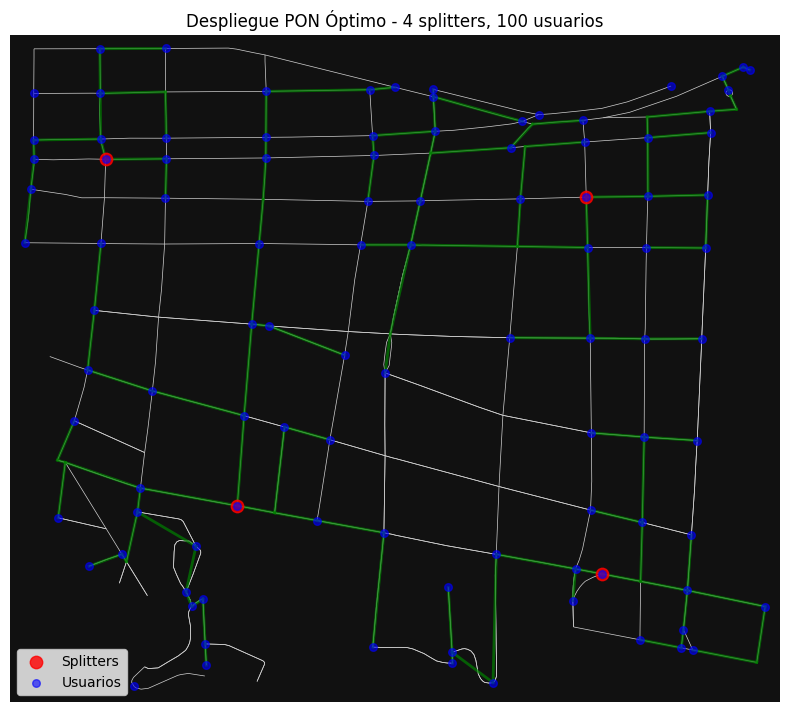

In [27]:
# ========== VISUALIZACIÓN ESTÁTICA (matplotlib) ==========
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_linewidth=0.5, edge_color='lightgray')

# Dibujar rutas de fibra instaladas (verde)
for (u,v) in installed_edges:
    xs = [G.nodes[u]['x'], G.nodes[v]['x']]
    ys = [G.nodes[u]['y'], G.nodes[v]['y']]
    ax.plot(xs, ys, color='green', linewidth=2, alpha=0.7, zorder=2)

# Dibujar splitters (rojo)
splitter_points = [Point(G.nodes[s]['x'], G.nodes[s]['y']) for s in installed_splitters]
if splitter_points:
    splitter_gdf = gpd.GeoDataFrame(geometry=splitter_points, crs=nodes_gdf.crs)
    splitter_gdf.plot(ax=ax, color='red', markersize=80, alpha=0.8, zorder=3, label='Splitters')

# Dibujar usuarios (azul)
users_gdf.plot(ax=ax, color='blue', markersize=30, alpha=0.6, zorder=3, label='Usuarios')

ax.legend()
plt.title(f'Despliegue PON Óptimo - {len(installed_splitters)} splitters, {len(users_gdf)} usuarios')
plt.tight_layout()
plt.show()


In [28]:
# ========== VISUALIZACIÓN INTERACTIVA (folium) ==========
import folium
from folium import plugins

# Reproyectar a WGS84 (lat/lon) para folium
nodes_wgs84 = nodes_gdf.to_crs(epsg=4326)
users_wgs84 = users_gdf.to_crs(epsg=4326)

# Calcular centro del mapa
center = [users_wgs84.geometry.y.mean(), users_wgs84.geometry.x.mean()]

# Crear mapa base
m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')

# Capa 1: Rutas de fibra Manhattan (líneas verdes)
fiber_group = folium.FeatureGroup(name='Fibra Óptica (Rutas Manhattan)')
for (u,v) in installed_edges:
    node_u = nodes_wgs84.loc[u]
    node_v = nodes_wgs84.loc[v]
    coords = [
        [node_u.geometry.y, node_u.geometry.x],
        [node_v.geometry.y, node_v.geometry.x]
    ]
    # Calcular distancia de este segmento
    segment_length = edge_length_map.get(
        edge_index_lookup.get((u,v), edge_index_lookup.get((v,u), -1)), 
        0
    )
    
    folium.PolyLine(
        coords,
        color='green',
        weight=3,
        opacity=0.7,
        popup=f'Fibra: {u} ↔ {v}<br>Longitud: {segment_length:.1f} m'
    ).add_to(fiber_group)
fiber_group.add_to(m)

# Capa 2: Splitters (marcadores rojos)
splitter_group = folium.FeatureGroup(name='Splitters Instalados')
for s in installed_splitters:
    node = nodes_wgs84.loc[s]
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    
    # Calcular Power Budget promedio para usuarios de este splitter
    splitter_losses = [compute_optical_loss_for_path(path_lengths[(u,s)], SPLIT_RATIO) 
                       for (u, sp) in assignments if sp == s]
    avg_loss = np.mean(splitter_losses) if splitter_losses else 0
    
    folium.Marker(
        location=[node.geometry.y, node.geometry.x],
        popup=folium.Popup(
            f"<b>Splitter {s}</b><br>"
            f"Usuarios conectados: {users_count}/{SPLIT_RATIO}<br>"
            f"Utilización: {users_count/SPLIT_RATIO*100:.1f}%<br>"
            f"Pérdida óptica promedio: {avg_loss:.2f} dB<br>"
            f"Power Budget: {POWER_BUDGET_DB:.1f} dB",
            max_width=300
        ),
        tooltip=f"Splitter {s} ({users_count} usuarios)",
        icon=folium.Icon(color='red', icon='signal', prefix='fa')
    ).add_to(splitter_group)
splitter_group.add_to(m)

# Capa 3: Usuarios (marcadores azules con info de Power Budget)
user_group = folium.FeatureGroup(name='Usuarios')
for idx, row in users_wgs84.iterrows():
    assigned_splitter = next((s for (u, s) in assignments if u == idx), None)
    distance = path_lengths.get((idx, assigned_splitter), 0) if assigned_splitter else 0
    loss = compute_optical_loss_for_path(distance, SPLIT_RATIO) if assigned_splitter else 0
    margin = POWER_BUDGET_DB - loss
    latency = propagation_latency_us(distance) if assigned_splitter else 0
    
    # Color según margen de Power Budget
    if margin > 5:
        marker_color = 'darkblue'  # Excelente margen
    elif margin > 2:
        marker_color = 'blue'      # Buen margen
    elif margin > 0:
        marker_color = 'lightblue' # Margen ajustado
    else:
        marker_color = 'orange'    # Violación (no debería ocurrir)
    
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        popup=folium.Popup(
            f"<b>Usuario {idx}</b><br>"
            f"Splitter asignado: {assigned_splitter}<br>"
            f"<b>Distancia Manhattan: {distance:.1f} m</b><br>"
            f"Pérdida óptica: {loss:.2f} dB<br>"
            f"Power Budget disponible: {POWER_BUDGET_DB:.1f} dB<br>"
            f"Margen: {margin:.2f} dB<br>"
            f"Latencia: {latency:.2f} µs<br>"
            f"Cumple Power Budget: {'✓' if loss <= POWER_BUDGET_DB else '✗'}",
            max_width=300
        ),
        tooltip=f"Usuario {idx} (margen: {margin:.1f} dB)",
        color=marker_color,
        fill=True,
        fillColor=marker_color,
        fillOpacity=0.7
    ).add_to(user_group)
user_group.add_to(m)

# Agregar control de capas y pantalla completa
folium.LayerControl().add_to(m)
plugins.Fullscreen().add_to(m)

# Agregar leyenda mejorada con info de Power Budget
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 250px; height: 180px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:13px; padding: 10px">
<p><b>Leyenda - Despliegue PON</b></p>
<p><i class="fa fa-signal" style="color:red"></i> Splitters ({} instalados)</p>
<p><span style="color:blue">●</span> Usuarios ({} conectados)</p>
<p><span style="color:green">━</span> Fibra (rutas Manhattan)</p>
<p><b>Power Budget:</b> {:.1f} dB</p>
<p><b>Ratio:</b> 1:{} (max)</p>
<p style="font-size:11px; margin-top:5px">
<b>Color usuarios:</b><br>
● Azul oscuro: margen >5dB<br>
● Azul: margen >2dB<br>
● Azul claro: margen 0-2dB
</p>
</div>
'''.format(len(installed_splitters), len(users_gdf), POWER_BUDGET_DB, SPLIT_RATIO)
m.get_root().html.add_child(folium.Element(legend_html))

# Mostrar mapa
m

# Al final de la celda, agrega:
m.save('mapa_despliegue_pon.html')
print("Mapa guardado en: mapa_despliegue_pon.html")


Mapa guardado en: mapa_despliegue_pon.html


In [29]:
# ========== MÉTRICAS DEL DESPLIEGUE ==========
# Calcular utilización de splitters
splitter_usage = {}
for s in installed_splitters:
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    splitter_usage[s] = users_count

avg_utilization = np.mean(list(splitter_usage.values())) / SPLIT_RATIO * 100

# Calcular costo total
total_fiber_length = sum(edge_length_map[edge_index_lookup.get(e, edge_index_lookup.get((e[1], e[0])))] 
                         for e in installed_edges)
total_cost = total_fiber_length * COST_FIBER_PER_M + len(installed_splitters) * COST_SPLITTER

# Calcular estadísticas de pérdida óptica
optical_losses = [compute_optical_loss_for_path(path_lengths[(u,s)], SPLIT_RATIO) for (u,s) in assignments]
max_loss = max(optical_losses)
avg_loss = np.mean(optical_losses)

print("=" * 60)
print("RESUMEN DEL DESPLIEGUE PON ÓPTIMO")
print("=" * 60)
print(f"Splitters instalados:        {len(installed_splitters)}")
print(f"Usuarios conectados:         {len(users_gdf)}")
print(f"Utilización promedio:        {avg_utilization:.1f}%")
print(f"Fibra total instalada:       {total_fiber_length:.1f} m ({total_fiber_length/1000:.2f} km)")
print(f"Costo total estimado:        {total_cost:.2f} unidades")
print(f"Pérdida óptica promedio:     {avg_loss:.2f} dB")
print(f"Pérdida óptica máxima:       {max_loss:.2f} dB")
print(f"Cumple Power Budget ({POWER_BUDGET_DB:.0f} dB): {'SÍ' if max_loss <= POWER_BUDGET_DB else 'NO'}")
print("=" * 60)


RESUMEN DEL DESPLIEGUE PON ÓPTIMO
Splitters instalados:        4
Usuarios conectados:         100
Utilización promedio:        75.0%
Fibra total instalada:       7655.5 m (7.66 km)
Costo total estimado:        8455.52 unidades
Pérdida óptica promedio:     18.64 dB
Pérdida óptica máxima:       18.84 dB
Cumple Power Budget (30 dB): SÍ


## 12. Conclusiones y mejoras implementadas

### Cambios principales implementados según feedback del profesor:

1. **Áreas de estudio redefinidas**:
   - Se abandonó el enfoque de toda la ciudad de Valparaíso
   - Se implementaron 3 tipos de áreas: Urbana, Semi-Urbana y Rural
   - Cada área tiene características específicas de densidad y radio

2. **Posicionamiento de splitters basado en usuarios**:
   - **Antes**: Selección por intersecciones con alta conectividad
   - **Ahora**: Clustering (K-Means) de usuarios para determinar posiciones óptimas
   - Los splitters se ubican en nodos viales cercanos a centroides de clusters
   - Garantiza que los splitters estén cerca de grupos de usuarios reales

3. **Rutas con distancia Manhattan**:
   - Se mantiene el enfoque de rutas siguiendo calles reales
   - Optimizado con Numba para manejar grandes volúmenes de datos

4. **Proceso iterativo con Power Budget**:
   - **Antes**: ILP decide ubicación de splitters y asignaciones simultáneamente
   - **Ahora**: 
     - Los splitters se posicionan primero (clustering)
     - Se valida Power Budget antes del ILP
     - El ILP solo decide asignaciones óptimas
     - Si hay usuarios sin cobertura, se agregan splitters y se repite el proceso
   - Garantiza que todos los usuarios tengan cobertura (o se maximice la cobertura)

5. **Optimización con Numba**:
   - Funciones críticas decoradas con `@jit(nopython=True)`
   - Cálculos de distancia y Power Budget acelerados
   - Permite procesar datasets grandes sin problemas de rendimiento

### Ventajas del nuevo enfoque:

- **Escalabilidad**: Numba permite procesar miles de usuarios sin degradación
- **Realismo**: Splitters posicionados según ubicación real de usuarios
- **Cobertura garantizada**: Proceso iterativo asegura que todos los usuarios tengan servicio
- **Eficiencia**: ILP simplificado (menos variables de decisión) se resuelve más rápido
- **Flexibilidad**: Fácil adaptar a diferentes escenarios (urbano/rural)

### Arquitectura del flujo de trabajo:

```
1. Seleccionar área (urbana/semi-urbana/rural)
2. Extraer topología con OSMnx
3. Generar usuarios
4. Posicionar splitters (clustering)
    ↓
5. Calcular rutas Manhattan
6. Validar Power Budget
7. Resolver ILP
    ↓
8. ¿Todos cubiertos? → NO → Agregar splitters → Volver a paso 5
    ↓ SÍ
9. Validación final
10. Visualización
```

### Métricas clave del diseño:

- **Cobertura**: % de usuarios con servicio
- **Power Budget**: Todas las rutas cumplen requisitos ópticos
- **Eficiencia**: Utilización promedio de splitters
- **Costo**: Minimizado por ILP
- **Latencia**: Dentro de rangos aceptables para GPON

### Posibles extensiones futuras:

- Topología multi-nivel (cascada de splitters)
- Múltiples OLTs para áreas grandes
- Consideración de diferentes clases de servicio
- Análisis de resiliencia y redundancia
- Optimización multi-objetivo (costo vs. latencia)

## Guía de uso del notebook

### Selección de área de estudio:

En la celda de configuración, modificar la variable `AREA_TYPE`:

```python
AREA_TYPE = 'urbana'  # Opciones: 'urbana', 'semi_urbana', 'rural'
```

### Parámetros ajustables:

**Económicos:**
- `COST_FIBER_PER_M`: Costo por metro de fibra
- `COST_SPLITTER`: Costo de instalación de splitter
- `SPLIT_RATIO`: Capacidad máxima (usuarios por splitter)

**Power Budget:**
- `TX_POWER_DBM`: Potencia transmitida por OLT
- `RX_SENSITIVITY_DBM`: Sensibilidad del receptor ONU
- `SYSTEM_MARGIN_DB`: Margen de sistema

**Iteración:**
- `MAX_ITERATIONS`: Máximo de iteraciones para reposicionamiento
- `MIN_COVERAGE`: Cobertura mínima requerida (0.95 = 95%)

### Interpretación de visualizaciones:

**Mapa estático:**
- Líneas grises: Red vial
- Líneas verdes: Fibra instalada (rutas Manhattan)
- Puntos rojos: Splitters
- Puntos azules: Usuarios

**Mapa interactivo:**
- Click en marcadores para detalles
- Información de Power Budget por usuario
- Utilización de cada splitter
- Latencias y distancias

### Flujo de ejecución:

1. Ejecutar celdas en orden secuencial
2. El proceso iterativo se ejecuta automáticamente
3. Si no se alcanza cobertura completa en MAX_ITERATIONS, revisar:
   - Aumentar `POWER_BUDGET_DB`
   - Reducir `SPLIT_RATIO`
   - Ajustar área de estudio (radio menor)

### Optimización del rendimiento:

- Numba compila funciones en la primera ejecución (puede tardar)
- Ejecuciones posteriores son mucho más rápidas
- Para datasets muy grandes (>500 usuarios), considerar aumentar `time_limit` del ILP

## 13. Exportación de resultados

In [30]:
# Crear resumen de resultados
results_summary = {
    'area_type': AREA_TYPE,
    'num_users': len(user_ids),
    'num_splitters': len(installed_splitters),
    'num_assignments': len(assignments),
    'coverage_pct': len(assignments)/len(user_ids)*100 if len(user_ids) > 0 else 0,
    'total_cost': solution['cost'],
    'iterations': iteration,
    'power_budget_db': POWER_BUDGET_DB,
    'split_ratio': SPLIT_RATIO
}

# Guardar en CSV
results_df = pd.DataFrame([results_summary])
results_df.to_csv(f'resultados_{AREA_TYPE}.csv', index=False)

# Guardar asignaciones detalladas
if len(assignments) > 0:
    assignments_data = []
    for u, s in assignments:
        length_m = path_lengths[(u, s)]
        loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
        margin_db = POWER_BUDGET_DB - loss_db
        latency_us = propagation_latency_us(length_m)
        
        assignments_data.append({
            'user_id': u,
            'splitter_id': s,
            'distance_m': length_m,
            'optical_loss_db': loss_db,
            'power_margin_db': margin_db,
            'latency_us': latency_us,
            'compliant': loss_db <= POWER_BUDGET_DB
        })
    
    assignments_df = pd.DataFrame(assignments_data)
    assignments_df.to_csv(f'asignaciones_{AREA_TYPE}.csv', index=False)
    
    print(f"\nResultados exportados:")
    print(f"  - resultados_{AREA_TYPE}.csv")
    print(f"  - asignaciones_{AREA_TYPE}.csv")
    print(f"  - mapa_despliegue_pon.html (del mapa interactivo)")

# Mostrar resumen final
print(f"\n{'='*70}")
print(f"RESUMEN FINAL - ÁREA {AREA_TYPE.upper()}")
print(f"{'='*70}")
for key, value in results_summary.items():
    if isinstance(value, float):
        print(f"{key:25s}: {value:.2f}")
    else:
        print(f"{key:25s}: {value}")
print(f"{'='*70}")


Resultados exportados:
  - resultados_urbana.csv
  - asignaciones_urbana.csv
  - mapa_despliegue_pon.html (del mapa interactivo)

RESUMEN FINAL - ÁREA URBANA
area_type                : urbana
num_users                : 100
num_splitters            : 4
num_assignments          : 96
coverage_pct             : 96.00
total_cost               : 8455.52
iterations               : 0
power_budget_db          : 30.00
split_ratio              : 32
